# S\&P 100 Experiment Plots

In [1]:
import torch
from matplotlib import pyplot as plt
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('')))
from MSM import utils

## Individual Threshold Plots

All Normal

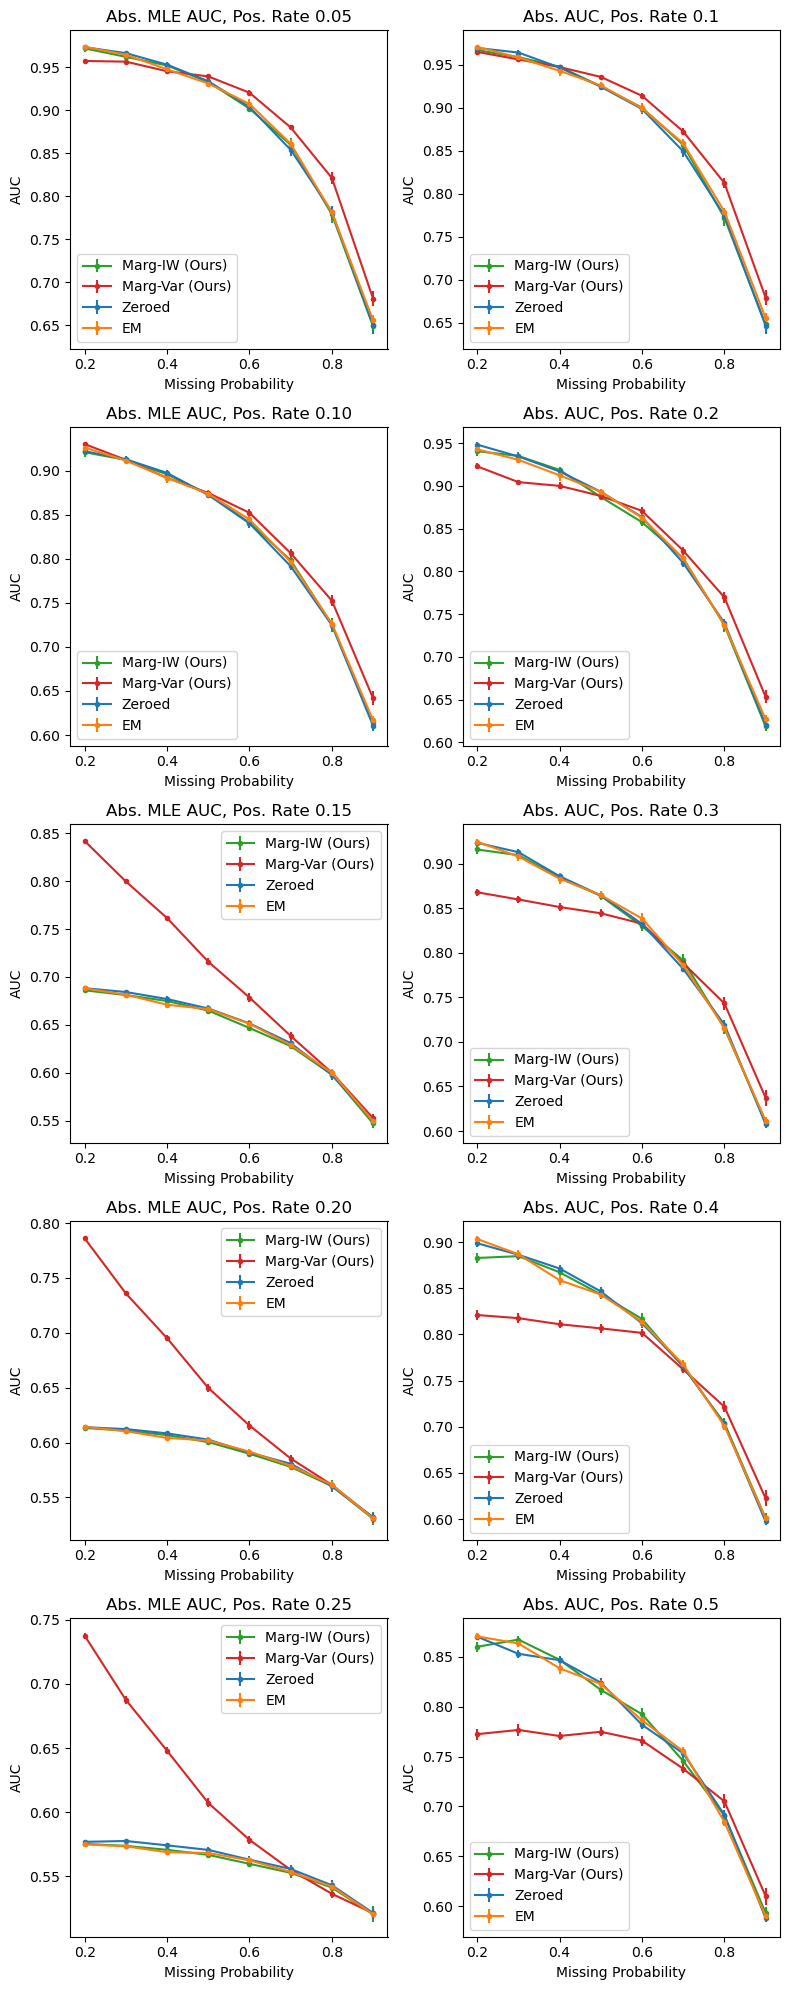

In [9]:
miss_probs = torch.arange(0.2, 0.91, step=0.1)
methods = ["iw","variational", "missdiff", "em"]
names = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0","C1", "C4"]
thresholds = [0.1, 0.01, 0.0]
threshold = thresholds[1]

ref_dat = torch.load(
    f"../real_world_experiments/Results/snp100/VaryMiss/{methods[0]}_slowlr_accuracy_list_miss_prob={miss_probs[0]:.1f}.pt",
    weights_only=True)
positive_rates = ref_dat["Threshold_NonAbs"]
abs_positive_rates = ref_dat["Threshold_Abs"]

fig, ax = plt.subplots(ncols=2, nrows=5, figsize=(8,20))
for i, method in enumerate(methods):
    data_list = []
    abs_data_list = []
    for miss_prob in miss_probs:
        file_name = f"../real_world_experiments/Results/snp100/VaryMiss/{method}_slowlr_accuracy_list_miss_prob={miss_prob:.1f}.pt"
        temp_dat = torch.load(file_name, weights_only=True)
        data_list.append(utils.data.get_ci(
            utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Normal"]),dim=0))
        abs_data_list.append(utils.data.get_ci(
            utils.data.recursive_tensorize(temp_dat["AUC_Abs_Normal"]),dim=0))
    data_ci = torch.stack(data_list, dim=-1)
    abs_data_ci = torch.stack(abs_data_list, dim=-1)

    # Plot results for each positive rate
    for rate_ind in range(5):
        ax[rate_ind,0].errorbar(miss_probs, data_ci[0, rate_ind], data_ci[2, rate_ind] - data_ci[0, rate_ind],
                                fmt="o-", label=names[i], color=colors[i], markersize=3)
        ax[rate_ind,1].errorbar(miss_probs, abs_data_ci[0, rate_ind], abs_data_ci[2, rate_ind] - abs_data_ci[0, rate_ind],
                                fmt="o-", label=names[i], color=colors[i], markersize=3)

for rate_ind in range(5):
    ax[rate_ind, 0].set_title(f"Abs. MLE AUC, Pos. Rate {positive_rates[rate_ind]:.2f}")
    ax[rate_ind, 1].set_title(f"Abs. AUC, Pos. Rate {abs_positive_rates[rate_ind]:.1f}")
    ax[rate_ind, 0].set_xlabel("Missing Probability")
    ax[rate_ind, 1].set_xlabel("Missing Probability")
    ax[rate_ind, 0].set_ylabel("AUC")
    ax[rate_ind, 1].set_ylabel("AUC")
    ax[rate_ind, 0].legend()
    ax[rate_ind, 1].legend()
fig.tight_layout()

All cumulative

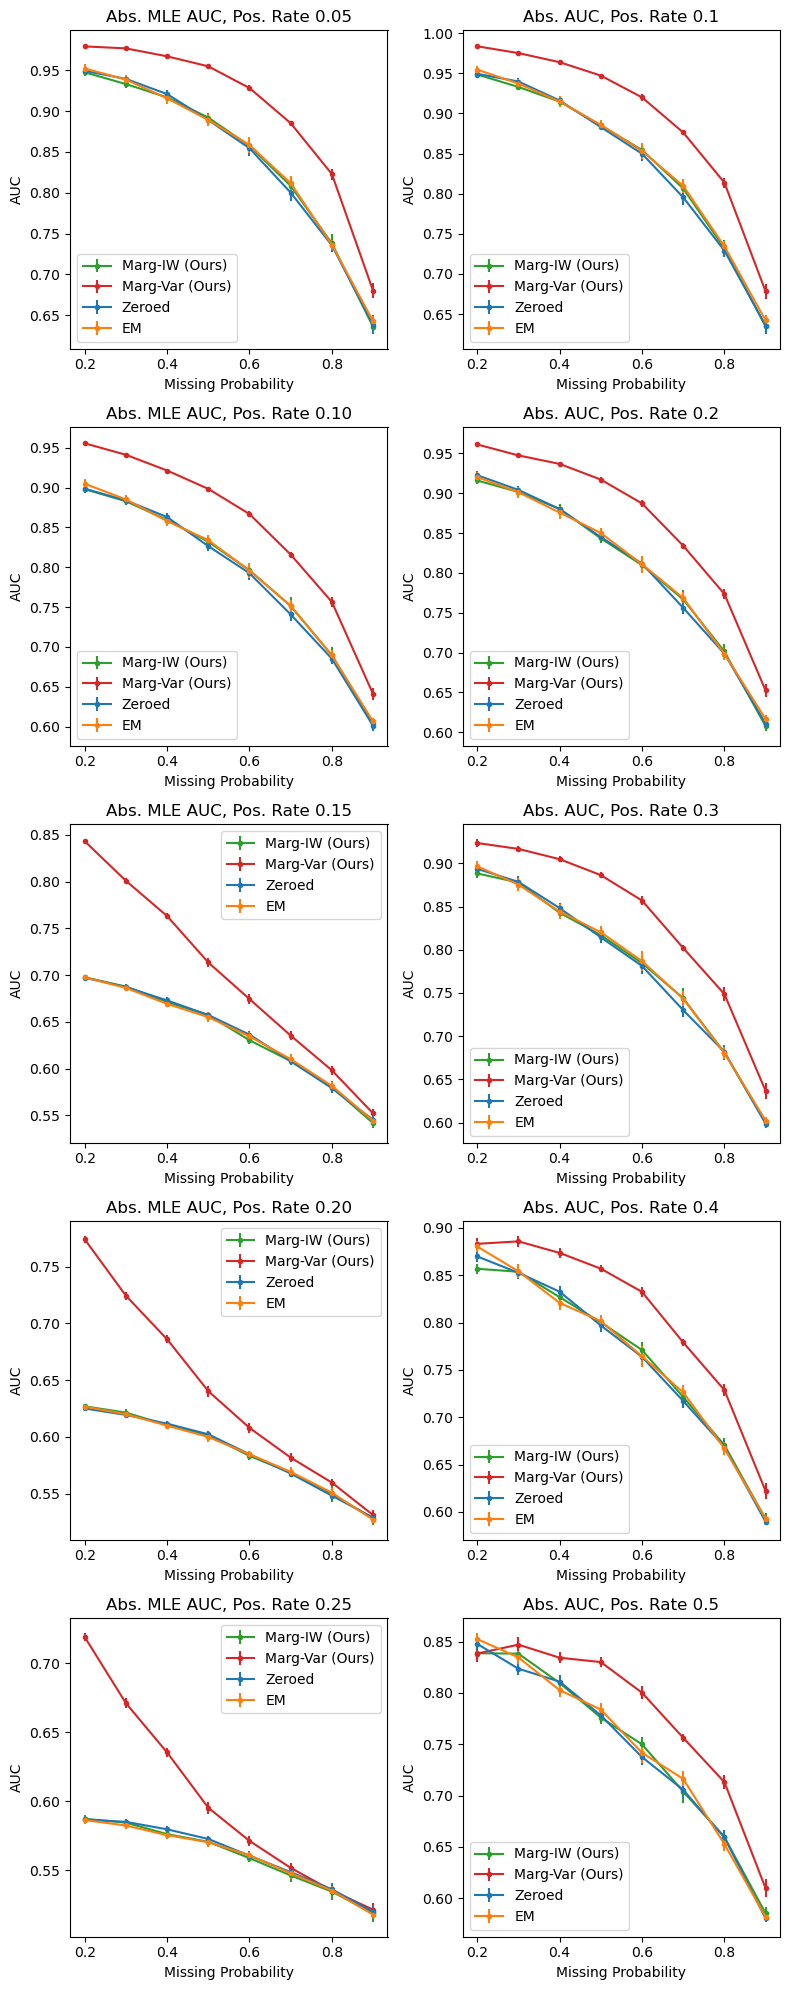

In [11]:
miss_probs = torch.arange(0.2, 0.91, step=0.1)
methods = ["iw","variational", "missdiff", "em"]
names = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0","C1", "C4"]
thresholds = [0.1, 0.01, 0.0]
threshold = thresholds[1]

ref_dat = torch.load(
    f"../real_world_experiments/Results/snp100/VaryMiss/{methods[0]}_slowlr_accuracy_list_miss_prob={miss_probs[0]:.1f}.pt",
    weights_only=True)
positive_rates = ref_dat["Threshold_NonAbs"]
abs_positive_rates = ref_dat["Threshold_Abs"]

fig, ax = plt.subplots(ncols=2, nrows=5, figsize=(8,20))
for i, method in enumerate(methods):
    data_list = []
    abs_data_list = []
    for miss_prob in miss_probs:
        file_name = f"../real_world_experiments/Results/snp100/VaryMiss/{method}_slowlr_accuracy_list_miss_prob={miss_prob:.1f}.pt"
        temp_dat = torch.load(file_name, weights_only=True)
        data_list.append(utils.data.get_ci(
            utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Cumulative"]),dim=0))
        abs_data_list.append(utils.data.get_ci(
            utils.data.recursive_tensorize(temp_dat["AUC_Abs_Cumulative"]),dim=0))
    data_ci = torch.stack(data_list, dim=-1)
    abs_data_ci = torch.stack(abs_data_list, dim=-1)

    # Plot results for each positive rate
    for rate_ind in range(5):
        ax[rate_ind,0].errorbar(miss_probs, data_ci[0, rate_ind], data_ci[2, rate_ind] - data_ci[0, rate_ind],
                                fmt="o-", label=names[i], color=colors[i], markersize=3)
        ax[rate_ind,1].errorbar(miss_probs, abs_data_ci[0, rate_ind], abs_data_ci[2, rate_ind] - abs_data_ci[0, rate_ind],
                                fmt="o-", label=names[i], color=colors[i], markersize=3)

for rate_ind in range(5):
    ax[rate_ind, 0].set_title(f"Abs. MLE AUC, Pos. Rate {positive_rates[rate_ind]:.2f}")
    ax[rate_ind, 1].set_title(f"Abs. AUC, Pos. Rate {abs_positive_rates[rate_ind]:.1f}")
    ax[rate_ind, 0].set_xlabel("Missing Probability")
    ax[rate_ind, 1].set_xlabel("Missing Probability")
    ax[rate_ind, 0].set_ylabel("AUC")
    ax[rate_ind, 1].set_ylabel("AUC")
    ax[rate_ind, 0].legend()
    ax[rate_ind, 1].legend()
fig.tight_layout()

Split

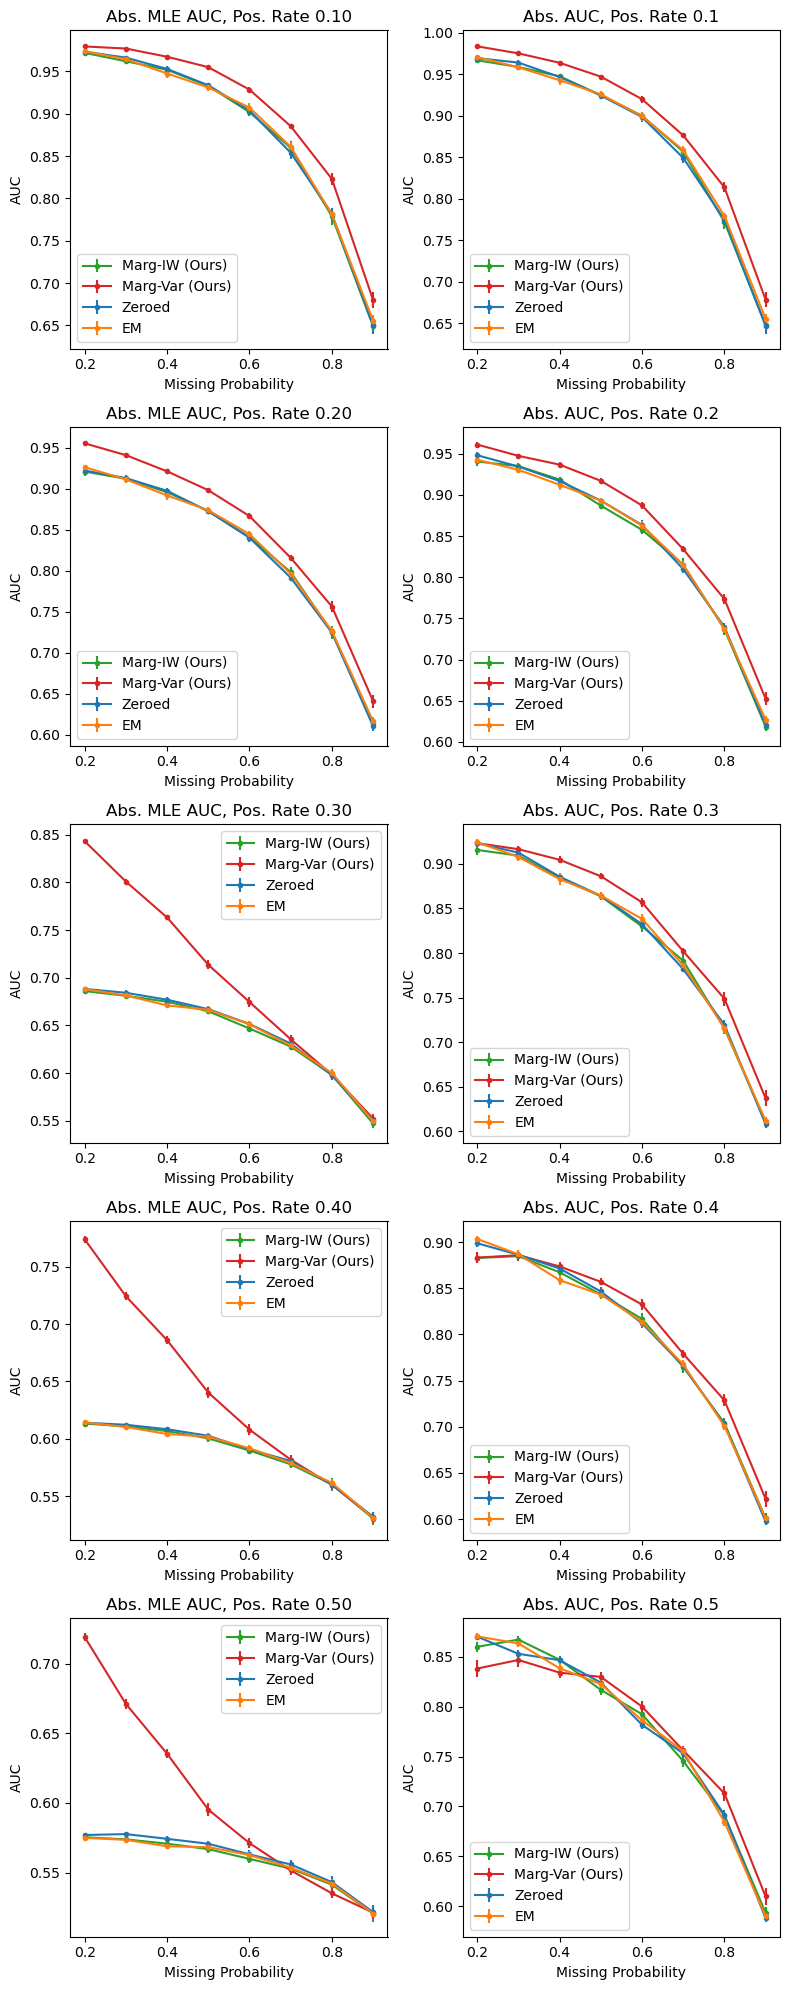

In [12]:
miss_probs = torch.arange(0.2, 0.91, step=0.1)
methods = ["iw","variational", "missdiff", "em"]
names = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0","C1", "C4"]
thresholds = [0.1, 0.01, 0.0]
threshold = thresholds[1]

ref_dat = torch.load(
    f"../real_world_experiments/Results/snp100/VaryMiss/{methods[0]}_slowlr_accuracy_list_miss_prob={miss_probs[0]:.1f}.pt",
    weights_only=True)
positive_rates = ref_dat["Threshold_NonAbs"]
abs_positive_rates = ref_dat["Threshold_Abs"]

fig, ax = plt.subplots(ncols=2, nrows=5, figsize=(8,20))
for i, method in enumerate(methods):
    data_list = []
    abs_data_list = []
    for miss_prob in miss_probs:
        file_name = f"../real_world_experiments/Results/snp100/VaryMiss/{method}_slowlr_accuracy_list_miss_prob={miss_prob:.1f}.pt"
        temp_dat = torch.load(file_name, weights_only=True)
        if "variational" in method:
            data_list.append(utils.data.get_ci(
                utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Cumulative"]),dim=0))
            abs_data_list.append(utils.data.get_ci(
                utils.data.recursive_tensorize(temp_dat["AUC_Abs_Cumulative"]),dim=0))
        else:
            data_list.append(utils.data.get_ci(
                utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Normal"]),dim=0))
            abs_data_list.append(utils.data.get_ci(
                utils.data.recursive_tensorize(temp_dat["AUC_Abs_Normal"]),dim=0))
    data_ci = torch.stack(data_list, dim=-1)
    abs_data_ci = torch.stack(abs_data_list, dim=-1)

    # Plot results for each positive rate
    for rate_ind in range(5):
        ax[rate_ind,0].errorbar(miss_probs, data_ci[0, rate_ind], data_ci[2, rate_ind] - data_ci[0, rate_ind],
                                fmt="o-", label=names[i], color=colors[i], markersize=3)
        ax[rate_ind,1].errorbar(miss_probs, abs_data_ci[0, rate_ind], abs_data_ci[2, rate_ind] - abs_data_ci[0, rate_ind],
                                fmt="o-", label=names[i], color=colors[i], markersize=3)

for rate_ind in range(5):
    ax[rate_ind, 0].set_title(f"Abs. MLE AUC, Pos. Rate {abs_positive_rates[rate_ind]:.2f}")
    ax[rate_ind, 1].set_title(f"Abs. AUC, Pos. Rate {abs_positive_rates[rate_ind]:.1f}")
    ax[rate_ind, 0].set_xlabel("Missing Probability")
    ax[rate_ind, 1].set_xlabel("Missing Probability")
    ax[rate_ind, 0].set_ylabel("AUC")
    ax[rate_ind, 1].set_ylabel("AUC")
    ax[rate_ind, 0].legend()
    ax[rate_ind, 1].legend()
fig.tight_layout()

## Summary Plots

cumulative

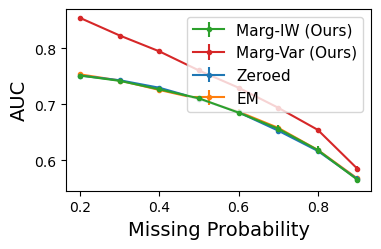

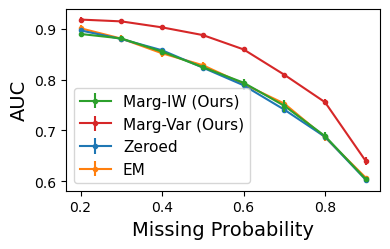

In [17]:
miss_probs = torch.arange(0.2, 0.91, step=0.1)
methods = ["iw", "variational", "missdiff", "em"]
labels = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0", "C1"]
thresholds = [0.1, 0.01, 0.]
threshold = thresholds[0]

ref_dat = torch.load(
    f"../real_world_experiments/Results/snp100/VaryMiss/{methods[0]}_slowlr_accuracy_list_miss_prob={miss_probs[0]:.1f}.pt",
    weights_only=True)
positive_rates = ref_dat["Threshold_NonAbs"]
abs_positive_rates = ref_dat["Threshold_Abs"]

fig, ax = plt.subplots(figsize=(4, 2.6))
fig2, ax2 = plt.subplots(figsize=(4, 2.6))
for i, method in enumerate(methods):
    data_list = []
    abs_data_list = []
    for miss_prob in miss_probs:
        file_name = f"../real_world_experiments/Results/snp100/VaryMiss/{method}_slowlr_accuracy_list_miss_prob={miss_prob:.1f}.pt"
        temp_dat = torch.load(file_name, weights_only=True)
        data_list.append(utils.data.get_ci(
            torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Cumulative"]),dim=-1),dim=0))
        abs_data_list.append(utils.data.get_ci(
            torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_Abs_Cumulative"]), dim=-1), dim=0))

    data_ci = torch.stack(data_list, dim=-1)
    abs_data_ci = torch.stack(abs_data_list, dim=-1)

    # Plot results for each positive rate

    
    ax.errorbar(miss_probs, data_ci[0], data_ci[2] - data_ci[0],
                fmt="o-", label=labels[i], color=colors[i], markersize=3, zorder=5-i)
    ax2.errorbar(miss_probs, abs_data_ci[0], abs_data_ci[2] - abs_data_ci[0],
                 fmt="o-", label=labels[i], color=colors[i], markersize=3, zorder=5-i)


ax.set_xlabel("Missing Probability", fontsize=14)
ax2.set_xlabel("Missing Probability", fontsize=14)
ax.set_ylabel("AUC", fontsize=14)
ax2.set_ylabel("AUC", fontsize=14)
ax.legend(fontsize=11)
ax2.legend(fontsize=11)
fig.tight_layout()
fig2.tight_layout()
fig.savefig("../plots/GGM/snp100_AbsMLE_AUC_cumulative.pdf")
fig2.savefig("../plots/GGM/snp100_Abs_AUC_cumulative.pdf")

mixed

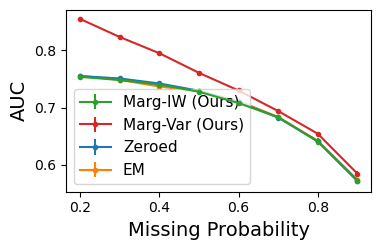

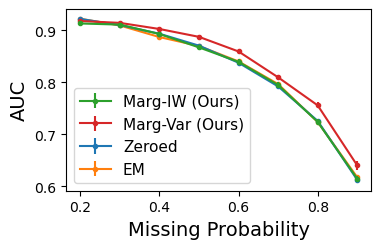

In [15]:
miss_probs = torch.arange(0.2, 0.91, step=0.1)
methods = ["iw","variational", "missdiff", "em"]
labels = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0", "C1"]
thresholds = [0.1, 0.01, 0.]
threshold = thresholds[0]

ref_dat = torch.load(
    f"../real_world_experiments/Results/snp100/VaryMiss/{methods[0]}_slowlr_accuracy_list_miss_prob={miss_probs[0]:.1f}.pt",
    weights_only=True)
positive_rates = ref_dat["Threshold_NonAbs"]
abs_positive_rates = ref_dat["Threshold_Abs"]

fig, ax = plt.subplots(figsize=(4, 2.6))
fig2, ax2 = plt.subplots(figsize=(4, 2.6))
for i, method in enumerate(methods):
    data_list = []
    abs_data_list = []
    for miss_prob in miss_probs:
        file_name = f"../real_world_experiments/Results/snp100/VaryMiss/{method}_slowlr_accuracy_list_miss_prob={miss_prob:.1f}.pt"
        
        temp_dat = torch.load(file_name, weights_only=True)
        
        if "variational" in method:
            data_list.append(utils.data.get_ci(
                torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Cumulative"]),dim=-1),dim=0))
            abs_data_list.append(utils.data.get_ci(
                torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_Abs_Cumulative"]), dim=-1), dim=0))
        
        else:
            # If method is variational use cumulative
            data_list.append(utils.data.get_ci(
                torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Normal"]),dim=-1),dim=0))
            abs_data_list.append(utils.data.get_ci(
                torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_Abs_Normal"]), dim=-1), dim=0))

    data_ci = torch.stack(data_list, dim=-1)
    abs_data_ci = torch.stack(abs_data_list, dim=-1)

    # Plot results for each positive rate

    
    ax.errorbar(miss_probs, data_ci[0], data_ci[2] - data_ci[0],
                fmt="o-", label=labels[i], color=colors[i], markersize=3, zorder=5-i)
    ax2.errorbar(miss_probs, abs_data_ci[0], abs_data_ci[2] - abs_data_ci[0],
                 fmt="o-", label=labels[i], color=colors[i], markersize=3, zorder=5-i)


ax.set_xlabel("Missing Probability", fontsize=14)
ax2.set_xlabel("Missing Probability", fontsize=14)
ax.set_ylabel("AUC", fontsize=14)
ax2.set_ylabel("AUC", fontsize=14)
ax.legend(fontsize=11)
ax2.legend(fontsize=11)
fig.tight_layout()
fig2.tight_layout()
fig.savefig("../plots/GGM/snp100_AbsMLE_AUC_mixed.pdf")
fig2.savefig("../plots/GGM/snp100_Abs_AUC_mixed.pdf")

normal

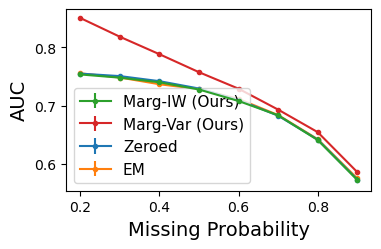

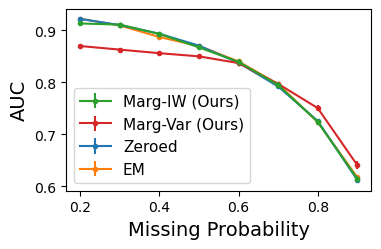

In [16]:
miss_probs = torch.arange(0.2, 0.91, step=0.1)
methods = ["iw","variational", "missdiff", "em"]
labels = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0", "C1"]
thresholds = [0.1, 0.01, 0.]
threshold = thresholds[0]

ref_dat = torch.load(
    f"../real_world_experiments/Results/snp100/VaryMiss/{methods[0]}_slowlr_accuracy_list_miss_prob={miss_probs[0]:.1f}.pt",
    weights_only=True)
positive_rates = ref_dat["Threshold_NonAbs"]
abs_positive_rates = ref_dat["Threshold_Abs"]

fig, ax = plt.subplots(figsize=(4, 2.6))
fig2, ax2 = plt.subplots(figsize=(4, 2.6))
for i, method in enumerate(methods):
    data_list = []
    abs_data_list = []
    for miss_prob in miss_probs:
        file_name = f"../real_world_experiments/Results/snp100/VaryMiss/{method}_slowlr_accuracy_list_miss_prob={miss_prob:.1f}.pt"
        temp_dat = torch.load(file_name, weights_only=True)
        data_list.append(utils.data.get_ci(
            torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_AbsMLE_Normal"]),dim=-1),dim=0))
        abs_data_list.append(utils.data.get_ci(
            torch.mean(utils.data.recursive_tensorize(temp_dat["AUC_Abs_Normal"]), dim=-1), dim=0))
    data_ci = torch.stack(data_list, dim=-1)
    abs_data_ci = torch.stack(abs_data_list, dim=-1)

    # Plot results for each positive rate    
    ax.errorbar(miss_probs, data_ci[0], data_ci[2] - data_ci[0],
                fmt="o-", label=labels[i], color=colors[i], markersize=3, zorder=5-i)
    ax2.errorbar(miss_probs, abs_data_ci[0], abs_data_ci[2] - abs_data_ci[0],
                 fmt="o-", label=labels[i], color=colors[i], markersize=3, zorder=5-i)


ax.set_xlabel("Missing Probability", fontsize=14)
ax2.set_xlabel("Missing Probability", fontsize=14)
ax.set_ylabel("AUC", fontsize=14)
ax2.set_ylabel("AUC", fontsize=14)
ax.legend(fontsize=11)
ax2.legend(fontsize=11)
fig.tight_layout()
fig2.tight_layout()
fig.savefig("../plots/GGM/snp100_AbsMLE_AUC_normal.pdf")
fig2.savefig("../plots/GGM/snp100_Abs_AUC_normal.pdf")